# Day 06 — Reporters Without Borders Data Day
### #30DayChartChallenge | April 2026

**How free is the press where you live?** Norway scores 92 out of 100. Eritrea scores 11. A bar chart showing the 2025 World Press Freedom Index — the gap between the best and worst is staggering.

**Data:**  
Reporters Without Borders (RSF) — World Press Freedom Index 2025.  
Source: [rsf.org/en/index](https://rsf.org/en/index)

**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'showtext' was built under R version 4.5.3"
Loading required package: sysfonts

Warning message:
"package 'sysfonts' was built under R version 4.5.3"
Loading required package: showtextdb

Warning message:
"package 'showtextdb' was built under R version 4.5.3"


In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

# set notebook preview to match ggsave dimensions
options(repr.plot.width = 13, repr.plot.height = 12, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------

df <- read.csv("../../data/day_06/rsf_press_freedom_index_2025.csv",
               stringsAsFactors = FALSE)

# order by score (lowest at top for horizontal bars)
df <- df[order(df$score), ]
df$country <- factor(df$country, levels = df$country)

# zone as ordered factor
df$zone <- factor(df$zone,
  levels = c("Good", "Satisfactory", "Problematic", "Very serious")
)

df

,rank,country,score,zone
,<int>,<fct>,<dbl>,<fct>
16,180,Eritrea,11.32,Very serious
15,179,North Korea,12.64,Very serious
14,178,China,14.80,Very serious
13,176,Iran,16.22,Very serious
12,173,Vietnam,19.74,Very serious
11,171,Russia,24.57,Very serious
10,151,India,32.96,Very serious
9,66,Japan,63.14,Problematic
8,63,Brazil,63.80,Problematic


In [4]:
# — theme & palette -----------------------------------------------------------

bg      <- "#0D1117"
txt     <- "#E6EDF3"
txt_dim <- "#8B949E"
txt_cap <- "#484F58"

zone_colors <- c(
  "Good"           = "#2ECC71",
  "Satisfactory"   = "#3498DB",
  "Problematic"    = "#F39C12",
  "Very serious"   = "#E74C3C"
)

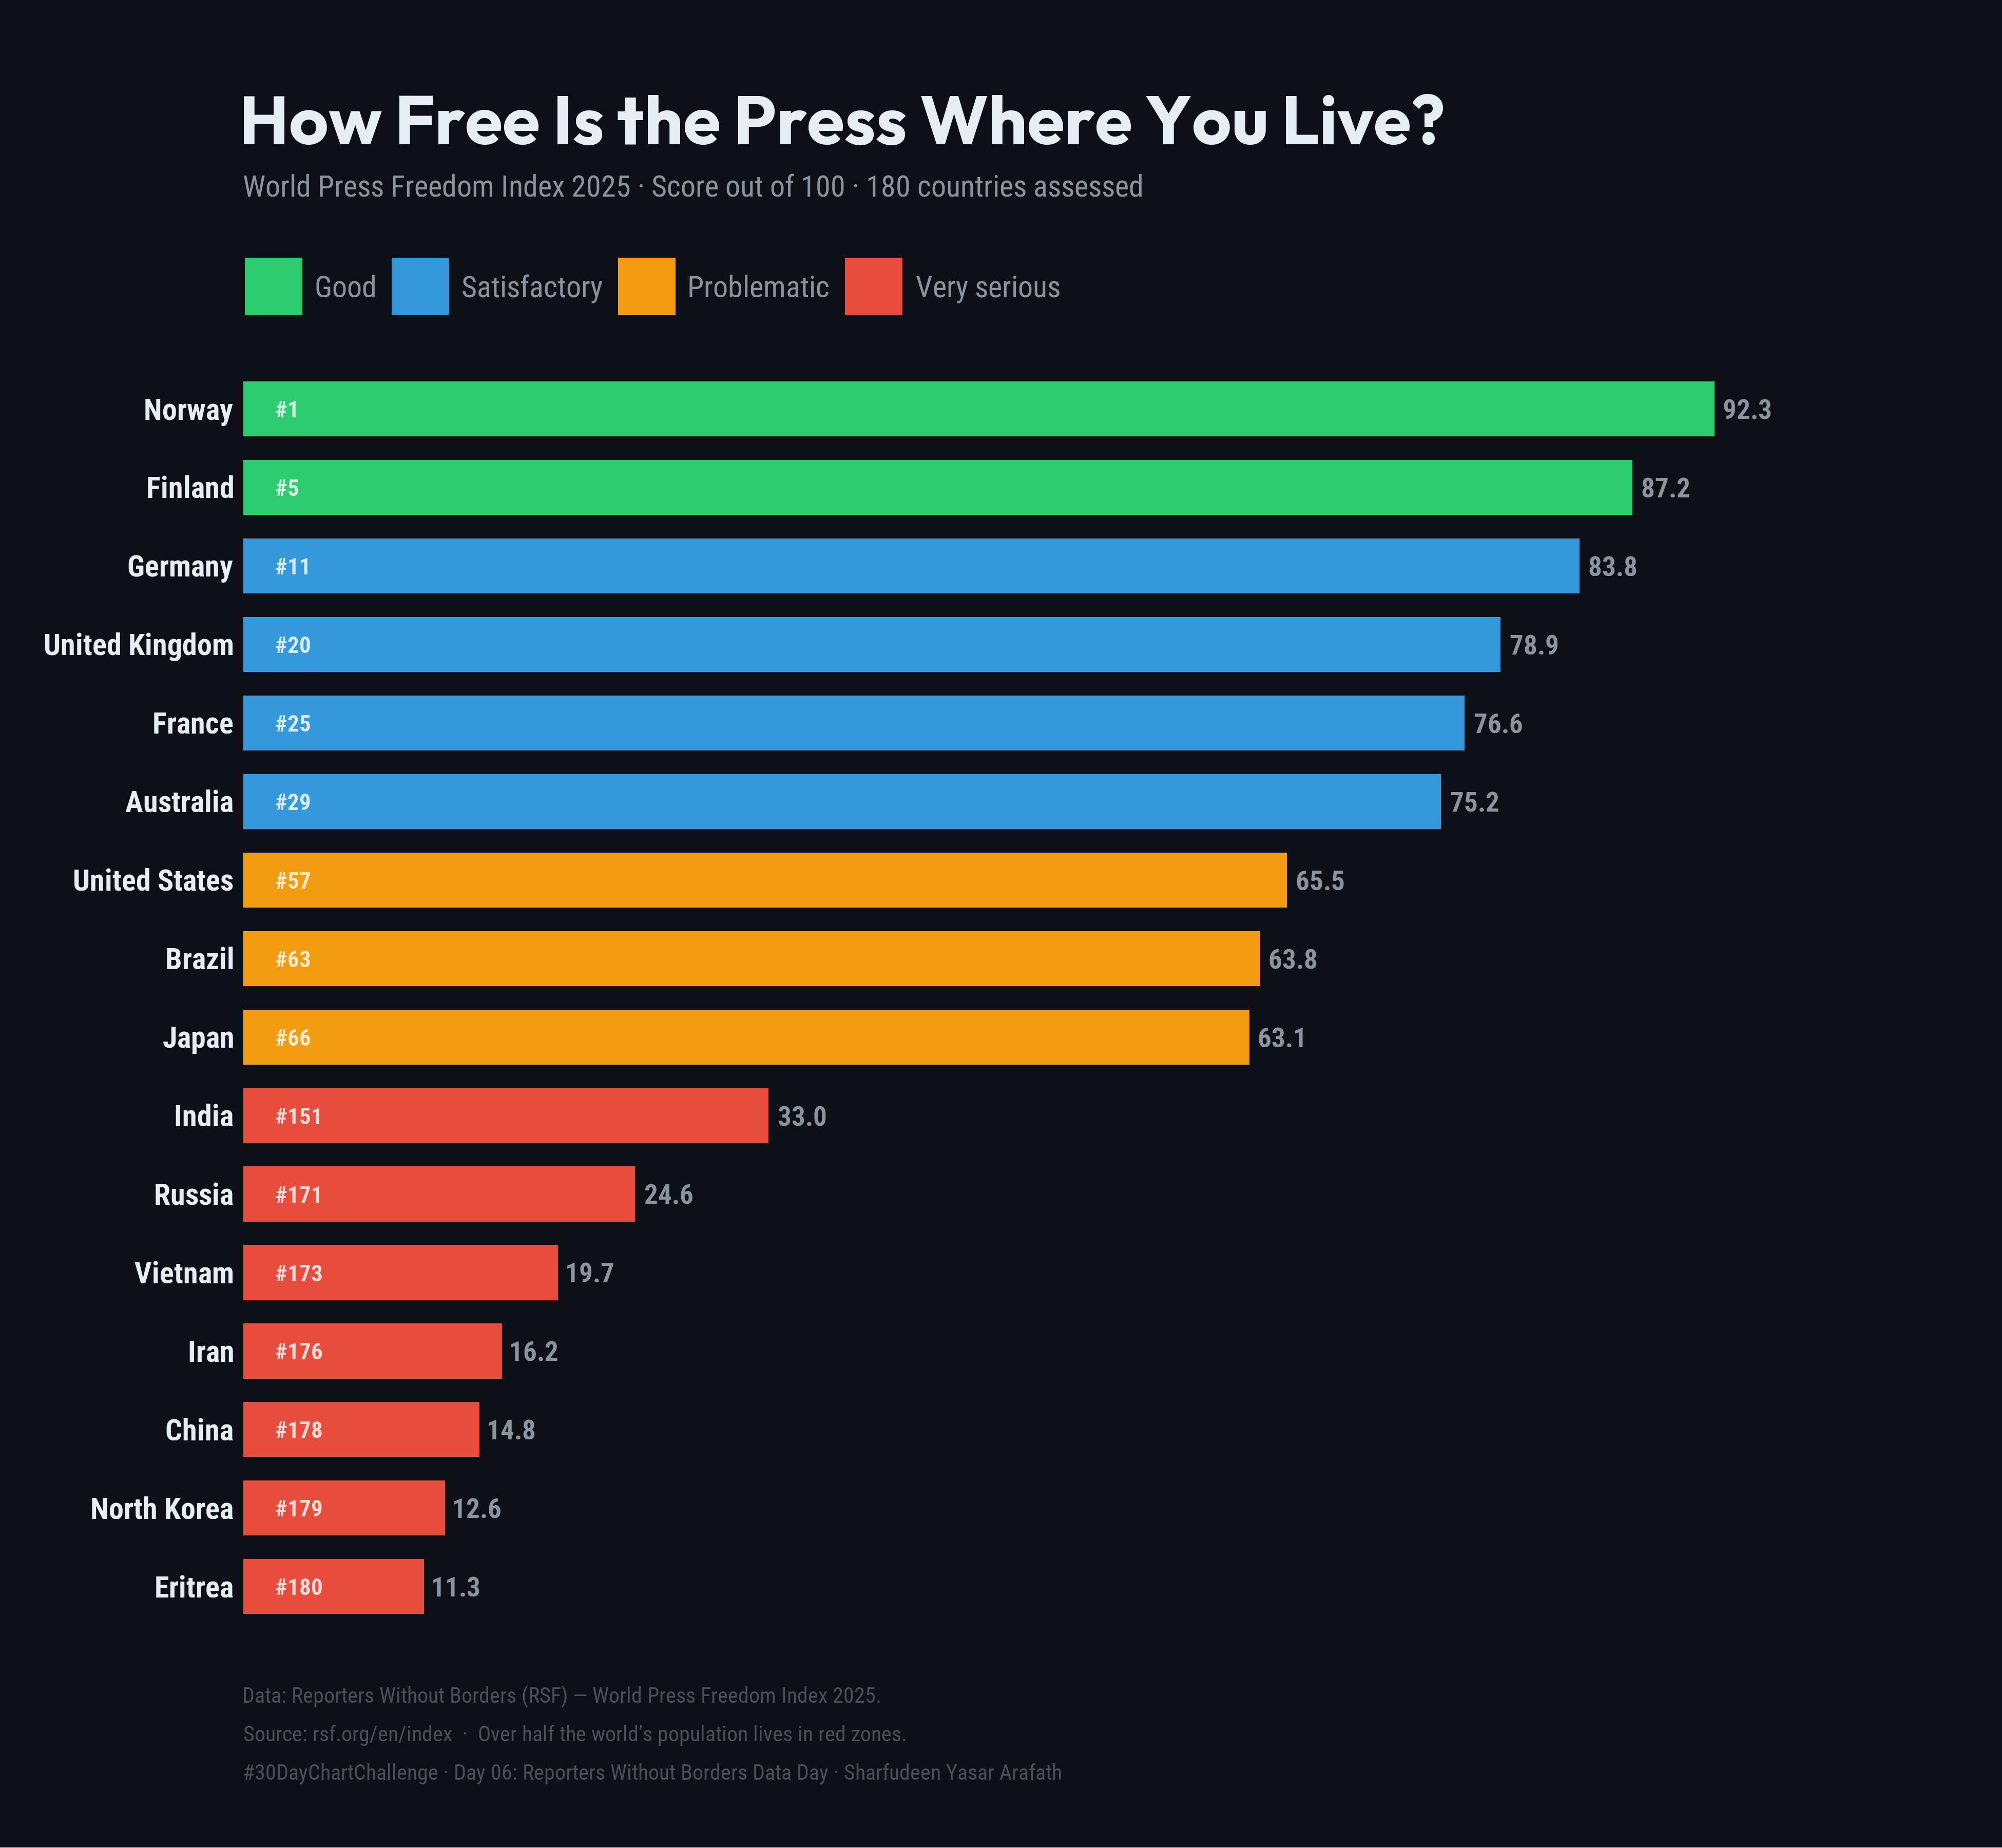

In [5]:
# — plot ----------------------------------------------------------------------

p <- ggplot(df, aes(x = score, y = country, fill = zone)) +

  # bars
  geom_col(width = 0.7) +

  # score labels at end of each bar
  geom_text(
    aes(label = sprintf("%.1f", score)),
    hjust = -0.2, color = txt_dim, family = "roboto_condensed",
    fontface = "bold", size = 4.5
  ) +

  # rank labels inside bar (left side)
  geom_text(
    aes(x = 2, label = paste0("#", rank)),
    hjust = 0, color = "white", family = "roboto_condensed",
    fontface = "bold", size = 3.8, alpha = 0.8
  ) +

  scale_fill_manual(values = zone_colors, name = NULL) +
  scale_x_continuous(limits = c(0, 105), expand = c(0, 0)) +

  labs(
    title    = "How Free Is the Press Where You Live?",
    subtitle = paste0(
      "World Press Freedom Index 2025 ",
      "\u00b7 Score out of 100 \u00b7 180 countries assessed"
    ),
    x        = NULL,
    y        = NULL,
    caption  = paste0(
      "Data: Reporters Without Borders (RSF) ",
      "\u2014 World Press Freedom Index 2025.\n",
      "Source: rsf.org/en/index  \u00b7  ",
      "Over half the world\u2019s population lives in red zones.\n",
      "#30DayChartChallenge \u00b7 Day 06: Reporters Without Borders Data Day \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_minimal(base_family = "roboto_condensed") +
  theme(
    plot.title       = element_text(family = "outfit", face = "bold", size = 32,
                                    hjust = 0, color = txt,
                                    margin = margin(t = 20, b = 8)),
    plot.subtitle    = element_text(size = 14, hjust = 0, color = txt_dim,
                                    margin = margin(b = 25)),
    plot.caption     = element_text(size = 10, hjust = 0, color = txt_cap,
                                    margin = margin(t = 25, b = 10),
                                    lineheight = 1.5),
    axis.text.y      = element_text(size = 14, color = txt, face = "bold",
                                    margin = margin(r = 5)),
    axis.text.x      = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_blank(),
    legend.position  = "top",
    legend.justification = "left",
    legend.text      = element_text(size = 14, color = txt_dim),
    legend.key.size  = unit(1, "cm"),
    legend.margin    = margin(b = 10),
    plot.background  = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin      = margin(25, 40, 20, 20)
  )

p

In [6]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_06_press_freedom.png",
       plot = p, width = 13, height = 12, dpi = 300, bg = bg)

cat("Done — saved to chart/day_06_press_freedom.png\n")

Done — saved to chart/day_06_press_freedom.png
